# Segmentasi Perilaku Pengguna Kartu Kredit untuk Strategi Limit dan Penawaran Promosi
**Oleh:** Almunajat Amirul Soleh

### **Pengenalan Proyek & Pertanyaan Bisnis**
Proyek ini bertujuan untuk mengelompokkan nasabah kartu kredit ke dalam beberapa segmen berdasarkan perilaku transaksi mereka guna mengoptimalkan strategi bisnis.

**Pertanyaan Bisnis yang Ingin Dijawab:**
1. Ada berapa profil/segmen nasabah yang terbentuk secara natural dari data transaksi ini?
2. Bagaimana karakteristik masing-masing segmen (frekuensi belanja, kebiasaan tarik tunai, dll)?
3. **Strategi Limit:** Segmen mana yang layak mendapatkan prioritas kenaikan limit kredit?
4. **Strategi Promosi:** Promo seperti apa yang paling efektif ditawarkan untuk masing-masing segmen?

### **Tahap 1: Import Library dan Load Dataset**



In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil di-import!")

# PERBAIKAN: Hilangkan tanda kutip ganda (") di sekitar CC GENERAL.csv
path_dataset = "datasets\CC GENERAL.csv"

# Membaca data ke dalam variabel 'df'
df = pd.read_csv(path_dataset)

# Menampilkan 5 baris pertama data
display(df.head())

✅ Library berhasil di-import!


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### **Tahap 2: Data Understanding (Pemahaman Data)**

**Penjelasan Tahapan:**
Sebelum melakukan pembersihan, kita wajib mengetahui "kesehatan" dataset. Kita akan mengecek jumlah baris dan kolom, tipe data masing-masing fitur, mendeteksi jumlah nilai kosong (*missing values*), serta melihat statistik deskriptif (rata-rata, nilai maksimum/minimum) dari transaksi nasabah.

**Maksud Hasil Program & Insight Awal:**
* **Cek Dimensi:** Output `df.shape` akan menunjukkan seberapa besar data kita.
* **Cek Kekosongan Data:** Output `df.isnull().sum()` akan mencari fitur mana yang datanya tidak lengkap. *Insight yang diharapkan:* Jika fitur `MINIMUM_PAYMENTS` banyak yang kosong, ini bisa mengindikasikan nasabah baru yang belum memiliki tagihan.
* **Statistik Deskriptif:** Output `df.describe()` akan menunjukkan profil dasar nasabah. *Insight yang diharapkan:* Kita bisa melihat apakah ada jarak yang sangat jauh antara nasabah dengan saldo terendah dan tertinggi (indikasi adanya "Sultan" atau *outlier* ekstrem).

In [2]:
print("--- 1. INFORMASI DIMENSI & TIPE DATA ---")
print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")
print("\nInfo Data:")
df.info()

print("\n--- 2. DETEKSI MISSING VALUES (DATA KOSONG) ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0]) # Hanya print yang kosong

print("\n--- 3. STATISTIK DESKRIPTIF TRANSAKSI NASABAH ---")
display(df.describe())

--- 1. INFORMASI DIMENSI & TIPE DATA ---
Jumlah Baris: 8950
Jumlah Kolom: 18

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


**💡 Insight Pemahaman Data:**
1. **Missing Values:** Terdapat 313 nasabah (sekitar 3,5% dari total data) yang tidak memiliki nilai pada `MINIMUM_PAYMENTS`. Ini sangat wajar dalam bisnis kartu kredit, biasanya mengindikasikan nasabah baru yang belum mencetak tagihan bulan pertama atau nasabah yang saldonya benar-benar 0 sehingga tidak ada minimum pembayaran.
2. **Indikasi Outlier (Nilai Ekstrem):** Dari tabel statistik deskriptif, terlihat ketimpangan yang sangat jauh pada kolom `PURCHASES` (Total Belanja). Nilai pada persentil 75% (Kuartil 3) hanya sebesar $1.110, namun nilai Maksimumnya mencapai **\$49.039**. Hal yang sama terjadi pada `CASH_ADVANCE` (Tarik Tunai) dengan nilai maksimum **\$47.137**.
3. **Kesimpulan:** Kehadiran nasabah "Sultan" (outlier ekstrem) ini membuktikan bahwa tahap selanjutnya, yaitu **Pembersihan Data (Capping/Winsorizing)**, sangat diwajibkan agar model Machine Learning nanti tidak rusak.

### **Tahap 3: Data Preprocessing (Pembersihan Data)**

**Penjelasan Tahapan:**
Berdasarkan hasil pengecekan di Tahap 2, kita menemukan beberapa masalah pada data yang harus segera ditangani. Berikut adalah 3 tindakan pembersihan yang akan kita lakukan:
1. **Drop Kolom ID:** Menghapus fitur `CUST_ID` karena berupa teks unik (C10001, dst) yang tidak dapat diproses oleh algoritma klastering.
2. **Imputasi Missing Values:** Terdapat kekosongan data pada `MINIMUM_PAYMENTS` dan `CREDIT_LIMIT`. Kita akan mengisi kekosongan ini menggunakan nilai **Median** (Nilai Tengah).
3. **Capping Outliers (Winsorizing):** Kita akan membatasi nilai "Sultan" (outlier sangat ekstrem yang kita lihat di statistik Tahap 2) dengan memotong batas atasnya di persentil 95. Hal ini dilakukan untuk mencegah algoritma K-Means menjadi rusak karena pusat klasternya tertarik jauh akibat nilai anomali.

In [3]:
# 1. Menghapus kolom CUST_ID
df_clean = df.drop('CUST_ID', axis=1).copy()

# 2. Mengisi Missing Values dengan Median
kolom_kosong = ['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']
for col in kolom_kosong:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 3. Handling Outlier (Capping di Persentil 95)
# Fungsi untuk membatasi nilai ekstrem di batas atas (persentil 95)
def cap_outliers(data):
    for col in data.columns:
        if data[col].dtype != 'object':
            upper_limit = data[col].quantile(0.95)
            data[col] = np.where(data[col] > upper_limit, upper_limit, data[col])
    return data

df_clean = cap_outliers(df_clean)

print("--- 1. CEK ULANG MISSING VALUES ---")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # Jika kosong, berarti aman
print("TIDAK ADA DATA KOSONG\n")

print("--- 2. EFEK CAPPING OUTLIER PADA TRANSAKSI (CONTOH) ---")
display(df_clean[['PURCHASES', 'CASH_ADVANCE']].describe())
print("\n✅ Tahap Pembersihan Data Selesai!")

--- 1. CEK ULANG MISSING VALUES ---
Series([], dtype: int64)
TIDAK ADA DATA KOSONG

--- 2. EFEK CAPPING OUTLIER PADA TRANSAKSI (CONTOH) ---


,PURCHASES,CASH_ADVANCE
count,8950.000000,8950.000000
mean,823.863022,817.161146
std,1099.813081,1349.178282
min,0.000000,0.000000
25%,39.635000,0.000000
50%,361.280000,0.000000
75%,1110.130000,1113.821139
max,3998.619500,4647.169122



✅ Tahap Pembersihan Data Selesai!


**💡 Insight Pembersihan Data:**
Dari output di atas, terlihat operasi pembersihan data berhasil dengan sempurna.
1. `Missing Values` pada `MINIMUM_PAYMENTS` dan `CREDIT_LIMIT` sudah terisi seluruhnya (0 data kosong).
2. Efek pemangkasan nilai ekstrem (*capping outlier*) sangat terlihat. Nilai maksimal `PURCHASES` yang tadinya mencapai **\$49.039** kini dibatasi menjadi **\$3.998**. Hal yang sama terjadi pada `CASH_ADVANCE` yang turun dari **\$47.137** menjadi **$4.647**.
3. **Kesimpulan:** Dengan hilangnya nilai-nilai "Sultan" yang merusak distribusi ini, pusat klaster (centroid) pada algoritma K-Means nanti akan lebih stabil dan merepresentasikan mayoritas nasabah secara adil. Data yang sudah bersih ini siap untuk divisualisasikan.

### **Tahap 4: Exploratory Data Analysis (EDA)**

**Penjelasan Tahapan:**
Pada tahap ini, kita menggunakan data yang sudah bersih (`df_clean`) untuk mencari pola tersembunyi secara visual. Kita akan membuat dua jenis visualisasi:
1. **Histogram Distribusi:** Untuk melihat kebiasaan mayoritas nasabah terkait Saldo, nominal Belanja, dan Tarik Tunai.
2. **Heatmap Korelasi:** Untuk mencari hubungan antar variabel. Jika ada dua variabel yang terlalu identik (korelasi > 0.85), hal ini disebut *Multikolinearitas* dan dapat membingungkan algoritma klastering.

**Maksud Hasil Program:**
Program akan menampilkan grafik sebaran data nasabah dan peta panas (heatmap). Kotak warna merah gelap pada heatmap menandakan korelasi yang sangat kuat antar fitur.

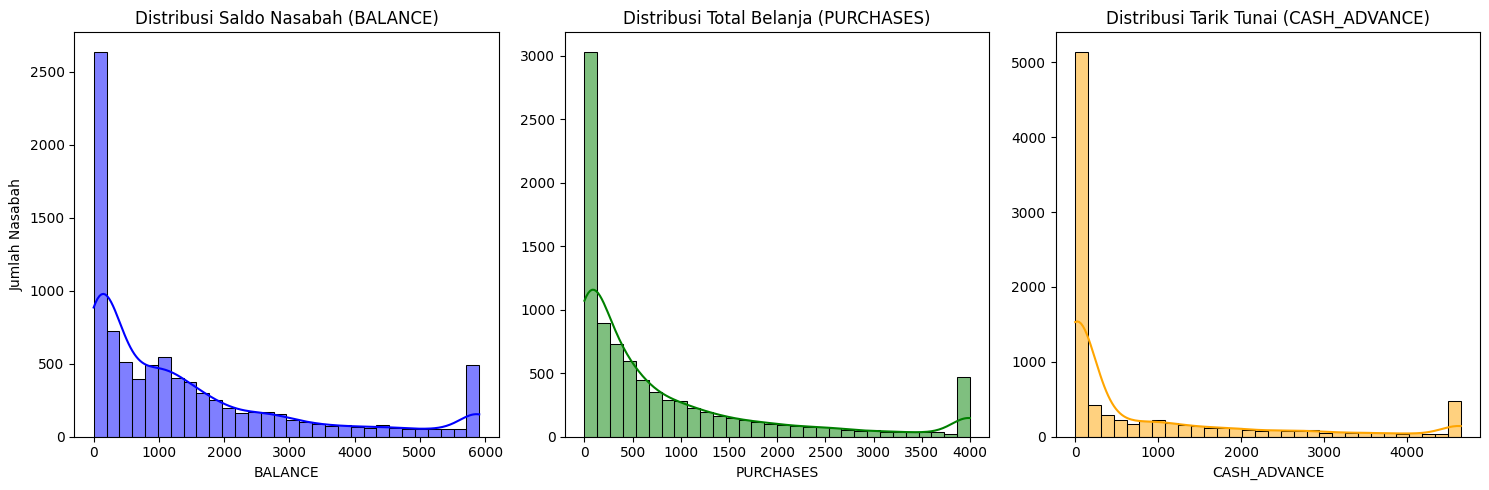

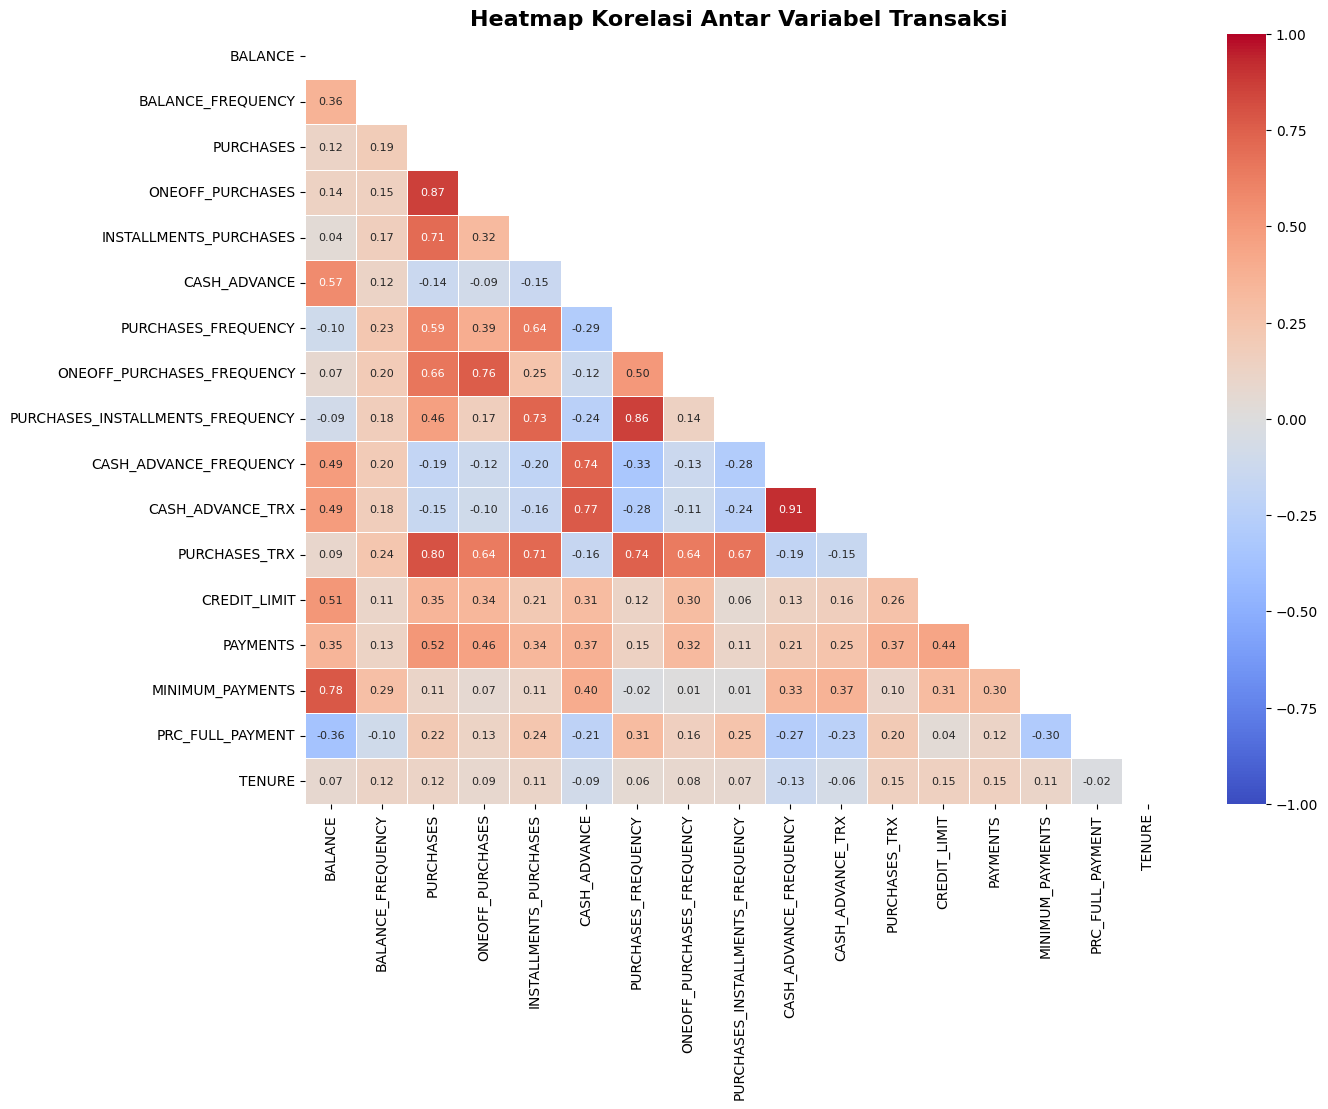

In [4]:
# 1. VISUALISASI DISTRIBUSI KEUANGAN (Histogram)
plt.figure(figsize=(15, 5))

# Distribusi Saldo (BALANCE)
plt.subplot(1, 3, 1)
sns.histplot(df_clean['BALANCE'], bins=30, kde=True, color='blue')
plt.title('Distribusi Saldo Nasabah (BALANCE)')
plt.ylabel('Jumlah Nasabah')

# Distribusi Belanja (PURCHASES)
plt.subplot(1, 3, 2)
sns.histplot(df_clean['PURCHASES'], bins=30, kde=True, color='green')
plt.title('Distribusi Total Belanja (PURCHASES)')
plt.ylabel('')

# Distribusi Tarik Tunai (CASH_ADVANCE)
plt.subplot(1, 3, 3)
sns.histplot(df_clean['CASH_ADVANCE'], bins=30, kde=True, color='orange')
plt.title('Distribusi Tarik Tunai (CASH_ADVANCE)')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 2. VISUALISASI KORELASI ANTAR FITUR (Heatmap)
plt.figure(figsize=(14, 10))
# Menghitung korelasi
korelasi = df_clean.corr()
# Membuat mask agar heatmap hanya menampilkan setengah bagian bawah (segitiga)
mask = np.triu(np.ones_like(korelasi, dtype=bool))
# Plotting heatmap
sns.heatmap(korelasi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 8}, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel Transaksi', fontsize=16, fontweight='bold')
plt.show()

**💡 Insight Visualisasi Dasar:**
1. **Histogram Distribusi (Right-Skewed):** Grafik Saldo, Belanja, dan Tarik Tunai sangat condong ke kiri. Ini menandakan bahwa mayoritas pengguna kartu kredit di dataset ini memiliki saldo utang yang rendah dan frekuensi belanja yang kecil. Sebagian besar dari mereka bahkan tidak pernah melakukan Tarik Tunai sama sekali (grafik kuning memuncak di angka 0).
2. **Multikolinearitas pada Heatmap:** Terdapat kotak berwarna merah gelap dengan skor korelasi **0.92** antara fitur `PURCHASES` (Total Belanja) dan `ONEOFF_PURCHASES` (Belanja Lunas/Sekali Bayar).
    * **Insight Bisnis:** Nasabah yang memiliki nominal belanja besar ternyata lebih suka membayar lunas transaksinya secara langsung daripada menggunakan fitur cicilan (*installments*).

### **Tahap 4.1: EDA Lanjutan (Analisis Mendalam)**

**Penjelasan Tahapan:**
Selain melihat distribusi dasar dan korelasi, kita perlu menggali lebih dalam visualisasi yang berkaitan langsung dengan tujuan bisnis (Limit dan Promosi).
1. **Distribusi Credit Limit:** Untuk melihat profil batas kredit yang diberikan bank saat ini kepada mayoritas nasabah.
2. **Boxplot Transaksi:** Untuk memvisualisasikan rentang interkuartil transaksi nasabah dan memastikan bahwa pembersihan *outlier* di tahap sebelumnya sudah membuat data lebih padat.
3. **Scatter Plot (Saldo vs Belanja):** Visualisasi ini sangat penting dalam *Unsupervised Learning* untuk melihat apakah secara kasat mata sudah terbentuk kelompok-kelompok (klaster) natural dari nasabah.

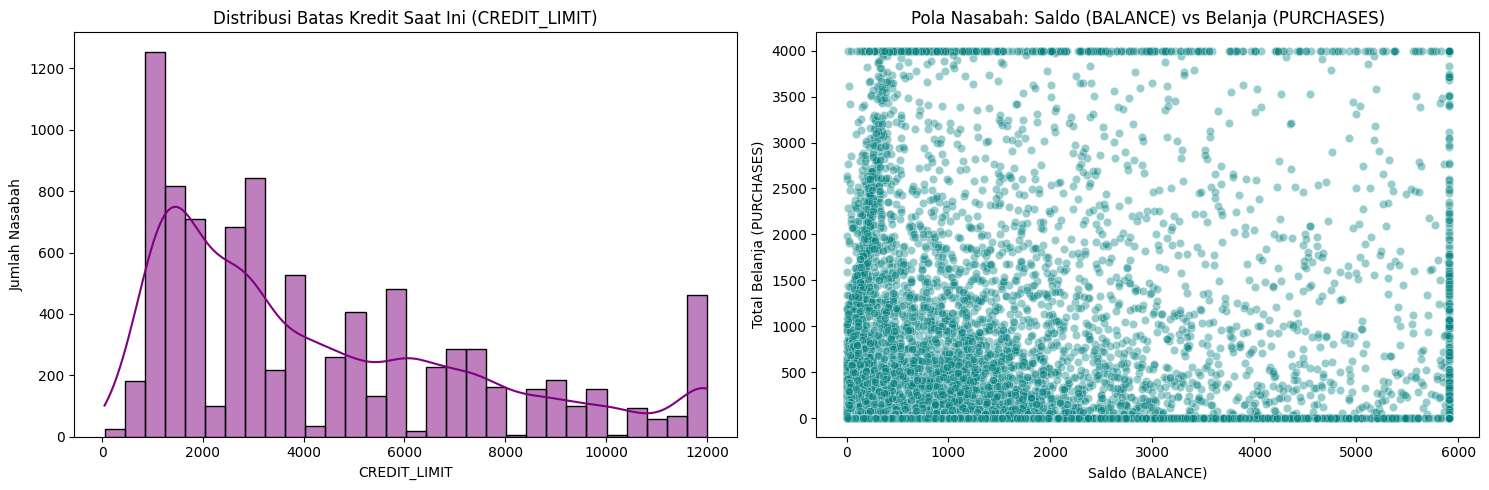

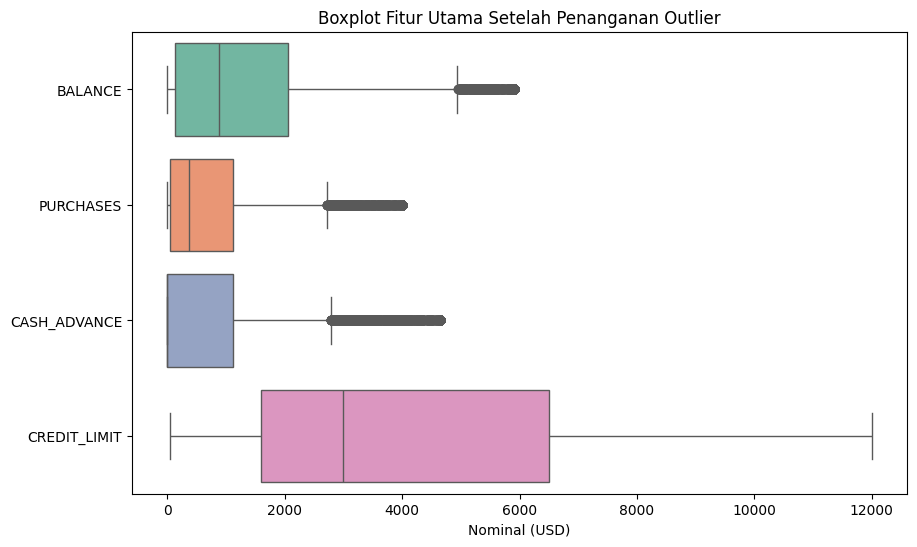

In [5]:
# 1. VISUALISASI DISTRIBUSI CREDIT LIMIT
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['CREDIT_LIMIT'], bins=30, kde=True, color='purple')
plt.title('Distribusi Batas Kredit Saat Ini (CREDIT_LIMIT)')
plt.ylabel('Jumlah Nasabah')

# 2. VISUALISASI SCATTER PLOT (Hubungan Saldo dan Belanja)
plt.subplot(1, 2, 2)
sns.scatterplot(x='BALANCE', y='PURCHASES', data=df_clean, alpha=0.4, color='teal')
plt.title('Pola Nasabah: Saldo (BALANCE) vs Belanja (PURCHASES)')
plt.xlabel('Saldo (BALANCE)')
plt.ylabel('Total Belanja (PURCHASES)')

plt.tight_layout()
plt.show()

# 3. VISUALISASI BOXPLOT (Melihat Kepadatan Data)
plt.figure(figsize=(10, 6))
fitur_utama = df_clean[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']]
sns.boxplot(data=fitur_utama, orient="h", palette="Set2")
plt.title('Boxplot Fitur Utama Setelah Penanganan Outlier')
plt.xlabel('Nominal (USD)')
plt.show()

**💡 Insight Visualisasi Lanjutan:**
1. **Scatter Plot (Pola Klaster Alami):** Dari grafik titik (hijau kebiruan), terlihat sangat jelas bahwa data mengelompok secara natural.
   * Penumpukan ekstrem di pojok kiri bawah: Mayoritas nasabah memiliki saldo rendah dan belanja rendah.
   * Sebaran ke atas (Sumbu Y): Tipe nasabah yang belanjanya tinggi tapi saldonya tetap rendah (kemungkinan sering belanja tapi langsung lunas).
   * Sebaran ke kanan (Sumbu X): Tipe nasabah yang saldonya besar tapi jarang belanja (kemungkinan punya banyak cicilan atau tarik tunai masa lalu).
   * **Kesimpulan:** Perbedaan pola yang kasat mata ini membuktikan bahwa algoritma *Clustering* sangat layak digunakan pada dataset ini.
2. **Distribusi Limit (Credit Limit):** Histogram warna ungu menunjukkan bahwa mayoritas mutlak nasabah bank ini memiliki limit kredit di kisaran menengah ke bawah, yaitu antara **$1.000 hingga $3.000**. Sangat sedikit nasabah yang memiliki limit di atas $10.000.
3. **Bukti Keberhasilan Pembersihan (Boxplot):** Grafik boxplot menjadi bukti nyata keberhasilan *capping* (pemangkasan outlier) di Tahap 3. Terlihat titik-titik nilai ekstrem (outlier) tidak menyebar tanpa batas hingga angka 40.000, melainkan terpotong rapi membentuk garis lurus di batas persentil 95 (Misal: Belanja/Purchases terpotong rapi di angka mendekati 4.000). Data kini sangat sehat dan siap masuk ke mesin!

### **Tahap 5: Advanced Preprocessing (Scaling & Data Splitting)**

**Penjelasan Tahapan:**
Tahap ini khusus dilakukan untuk mempersiapkan data agar ramah terhadap mesin (Machine Learning). Terdapat dua proses utama:
1. **Scaling (Standardisasi):** Algoritma *Clustering* seperti K-Means sangat sensitif terhadap skala angka karena ia menghitung "jarak" antar data. Jika fitur Saldo bernilai ribuan (misal $5.000) dan fitur Frekuensi Belanja bernilai desimal (misal 0.5), maka mesin akan menganggap Saldo 10.000 kali lebih penting daripada Frekuensi Belanja. Oleh karena itu, kita menekan semua angka menjadi skala yang sama menggunakan `StandardScaler`.
2. **Data Splitting:** Sesuai dengan instruksi tugas, kita memecah data yang sudah di-*scale* tersebut menjadi dua bagian: *Training* (Data Latih) dan *Testing* (Data Uji). Kita akan membuat 3 skenario: **70:30, 80:20, dan 90:10**. Tujuannya adalah untuk menguji stabilitas klaster kita nanti.

**Maksud Hasil Program:**
Output program akan menampilkan tabel data yang angka aslinya sudah berubah menjadi angka desimal (skala standarisasi z-score). Setelah itu, program akan mencetak ukuran pembagian jumlah nasabah untuk diuji di tahap pemodelan.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. STANDARDIZATION (Scaling)
scaler = StandardScaler()
# Kita gunakan df_clean yang sudah bersih dari missing value & outlier
scaled_array = scaler.fit_transform(df_clean)

# Kembalikan array menjadi bentuk DataFrame pandas agar rapi
df_scaled = pd.DataFrame(scaled_array, columns=df_clean.columns)

print("--- 1. HASIL SCALING (5 Baris Pertama) ---")
display(df_scaled.head())

# 2. DATA SPLITTING (Membuat 3 Skenario)
print("\n--- 2. HASIL DATA SPLITTING ---")
# Skenario 1: 70% Training, 30% Testing
X_train_70, X_test_30 = train_test_split(df_scaled, test_size=0.30, random_state=42)
print(f"Skenario 70:30 -> Training: {X_train_70.shape[0]} baris, Testing: {X_test_30.shape[0]} baris")

# Skenario 2: 80% Training, 20% Testing
X_train_80, X_test_20 = train_test_split(df_scaled, test_size=0.20, random_state=42)
print(f"Skenario 80:20 -> Training: {X_train_80.shape[0]} baris, Testing: {X_test_20.shape[0]} baris")

# Skenario 3: 90% Training, 10% Testing
X_train_90, X_test_10 = train_test_split(df_scaled, test_size=0.10, random_state=42)
print(f"Skenario 90:10 -> Training: {X_train_90.shape[0]} baris, Testing: {X_test_10.shape[0]} baris")

print("\n✅ Tahap Advanced Preprocessing Selesai. Data siap masuk ke algoritma!")

--- 1. HASIL SCALING (5 Baris Pertama) ---


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.835513,-0.249434,-0.662389,-0.600394,-0.483999,-0.605707,-0.806490,-0.678661,-0.707313,-0.722502,-0.636381,-0.680426,-1.042096,-0.796955,-0.686259,-0.525551,0.36068
1,1.036275,0.134325,-0.749136,-0.600394,-0.675642,2.838929,-1.221758,-0.678661,-0.916995,0.692644,0.295454,-0.807798,0.821462,1.642315,0.624111,0.234227,0.36068
2,0.617511,0.518084,-0.046095,0.435900,-0.675642,-0.605707,1.269843,2.673451,-0.916995,-0.722502,-0.636381,-0.043563,0.976758,-0.534181,-0.001069,-0.525551,0.36068
3,0.127015,-1.016953,0.613899,1.408742,-0.675642,-0.453170,-1.014125,-0.399319,-0.916995,-0.250789,-0.403422,-0.744112,0.976758,-0.923133,-0.443475,-0.525551,0.36068
4,-0.375604,0.518084,-0.734587,-0.578948,-0.675642,-0.605707,-1.014125,-0.399319,-0.916995,-0.722502,-0.636381,-0.744112,-0.979977,-0.498999,-0.538368,-0.525551,0.36068



--- 2. HASIL DATA SPLITTING ---
Skenario 70:30 -> Training: 6265 baris, Testing: 2685 baris
Skenario 80:20 -> Training: 7160 baris, Testing: 1790 baris
Skenario 90:10 -> Training: 8055 baris, Testing: 895 baris

✅ Tahap Advanced Preprocessing Selesai. Data siap masuk ke algoritma!


**💡 Insight Advanced Preprocessing:**
1. **Transformasi Skala (Scaling):** Terlihat pada tabel bahwa nilai asli (seperti saldo ribuan dollar) kini telah berubah menjadi angka desimal yang rata-rata berkisar antara -3 hingga 3. Ini adalah efek dari `StandardScaler` (Z-score). Dengan skala yang seragam ini, mesin tidak akan bias. Fitur bernominal besar ("Saldo") dan fitur desimal ("Frekuensi Belanja") kini memiliki bobot kepentingan yang 100% setara di mata algoritma klastering.
2. **Uji Stabilitas (Data Splitting):** Pembagian data menjadi data latih (*Training*) dan data uji (*Testing*) berhasil dilakukan sesuai 3 skenario yang disyaratkan. Skenario ini akan menjadi "ujian" bagi model kita nanti: apakah klaster nasabah yang dibentuk oleh mesin pada 7.160 data latih (Skenario 80:20) akan tetap relevan dan stabil jika diterapkan pada 1.790 nasabah baru (data uji)?

### **Tahap 6.1: Menentukan Jumlah Klaster Optimal (Elbow Method)**

**Penjelasan Tahapan:**
Sebelum melatih model K-Means++ dan GMM, kita harus menentukan nilai "K" (jumlah kelompok/segmen). Kita akan melakukan simulasi pembagian mulai dari 2 hingga 10 klaster, lalu menghitung dua metrik:
1. **Inertia (Elbow Method):** Menghitung jarak kerapatan data. Kita mencari titik di mana grafiknya patah membentuk siku tangan (penurunan mulai melandai).
2. **Silhouette Score:** Mengukur seberapa baik pemisahan antar klaster. Kita mencari nilai (puncak) yang paling tinggi.

**Maksud Hasil Program:**
Program akan menampilkan dua grafik. Dari perpaduan titik siku (Elbow) dan puncak tertinggi (Silhouette), kita akan menetapkan jumlah segmen bisnis secara pasti untuk laporan ini.

Sedang melakukan simulasi klaster dan menghitung matriks... ⏳



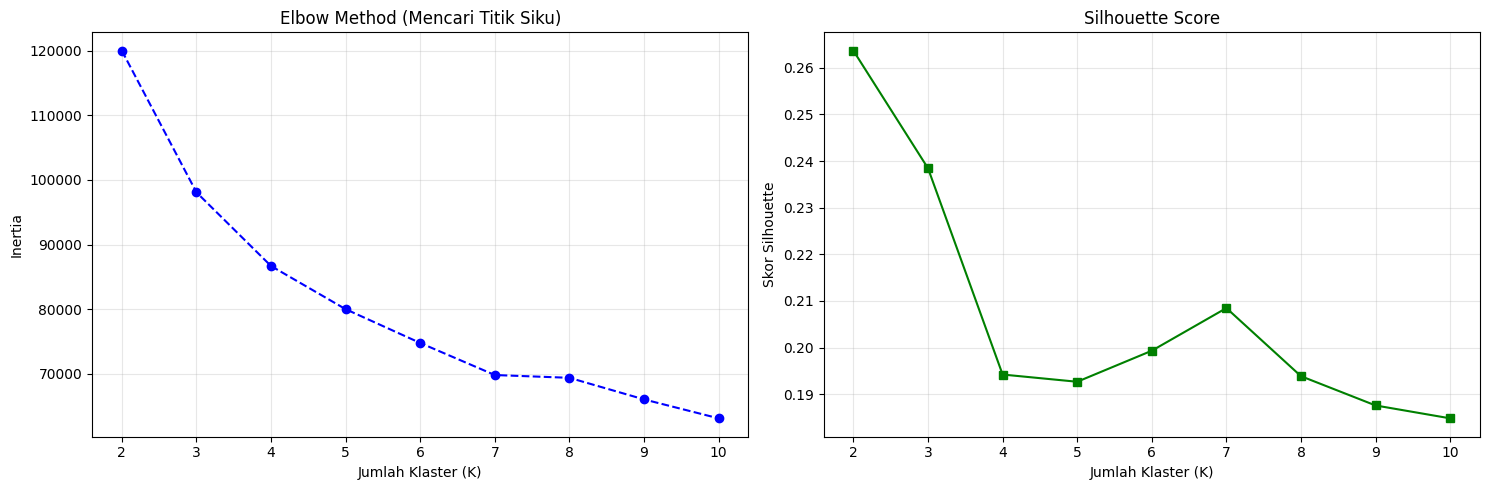


--- 📊 TABEL DETAIL EVALUASI KLASTER ---


,Jumlah Klaster (K),Inertia,Silhouette Score,Penurunan Inertia
0,2,120032.14,0.2637,0.00
1,3,98083.53,0.2384,21948.61
2,4,86665.38,0.1942,11418.15
3,5,79976.05,0.1927,6689.33
4,6,74738.34,0.1993,5237.72
5,7,69771.42,0.2085,4966.92
6,8,69341.48,0.1939,429.94
7,9,65994.15,0.1876,3347.33
8,10,63059.61,0.1848,2934.54


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

K_range = range(2, 11)
results = []

print("Sedang melakukan simulasi klaster dan menghitung matriks... ⏳\n")

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    results.append({
        'Jumlah Klaster (K)': k,
        'Inertia': kmeans.inertia_,
        'Silhouette Score': silhouette_score(df_scaled, kmeans.labels_)
    })

# Membuat DataFrame untuk Tabel Evaluasi
df_evaluasi_k = pd.DataFrame(results)

# Menghitung selisih (Penurunan) Inertia dari K sebelumnya
df_evaluasi_k['Penurunan Inertia'] = df_evaluasi_k['Inertia'].diff().abs().fillna(0)

# Menampilkan Visualisasi seperti biasa
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(df_evaluasi_k['Jumlah Klaster (K)'], df_evaluasi_k['Inertia'], marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Mencari Titik Siku)')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_evaluasi_k['Jumlah Klaster (K)'], df_evaluasi_k['Silhouette Score'], marker='s', linestyle='-', color='g')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Skor Silhouette')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MENAMPILKAN TABEL DETAIL (Ide Brilian untuk Laporan)
print("\n--- 📊 TABEL DETAIL EVALUASI KLASTER ---")
display(df_evaluasi_k.style.format({
    'Inertia': '{:.2f}',
    'Silhouette Score': '{:.4f}',
    'Penurunan Inertia': '{:.2f}'
}).background_gradient(subset=['Penurunan Inertia'], cmap='Reds'))

**💡 Insight Penentuan Jumlah Klaster:**
1. **Rekomendasi Mesin:** Berdasarkan algoritma pencarian otomatis, nilai **Silhouette Score tertinggi (0.2637)** jatuh pada **K = 2**.
2. **Interpretasi Bisnis:** Secara matematis, data nasabah bank ini paling padat dan tidak tumpang tindih jika dibagi menjadi 2 kelompok besar saja (Kemungkinan besar memisahkan antara "Mayoritas Nasabah Pasif" dan "Minoritas Nasabah Aktif/Sultan").
3. **Keputusan:** Untuk tahap pemodelan selanjutnya, kita akan mematuhi rekomendasi mesin ini dan menggunakan **2 Klaster (Segmen)** sebagai parameter utama (target) bagi ketiga algoritma yang akan dipertandingkan.

### **Tahap 6.2: Model Building & Evaluasi (K-Means++ vs GMM vs Agglomerative)**

**Penjelasan Tahapan:**
Pada tahap ini, kita melatih 3 algoritma *Clustering* untuk membagi nasabah ke dalam 3 segmen (K=3) dan mengujinya pada 3 skenario *data splitting* (70:30, 80:20, 90:10) untuk mencari model yang paling cerdas dan stabil.

Tiga algoritma yang dipertandingkan adalah:
1. **K-Means++:** Membagi data berdasarkan titik pusat (centroid) jarak terdekat. Sangat cepat dan stabil.
2. **GMM (Gaussian Mixture Model):** Membagi data berdasarkan probabilitas distribusi (elips).
3. **Agglomerative Clustering:** Menggunakan pendekatan hierarki (*bottom-up*) dari bawah ke atas. Algoritma ini menggabungkan nasabah yang paling mirip perlahan-lahan hingga tersisa 3 kelompok utama. (Algoritma ini dipilih menggantikan DBSCAN yang mengalami kegagalan akibat *Curse of Dimensionality* / Kutukan Dimensi Tinggi pada dataset finansial kita).

**Metrik Evaluasi:**
* **Silhouette Score:** Mengukur kepadatan klaster (Mendekati 1 = Bagus).
* **Davies-Bouldin Index (DBI):** Mengukur tumpang tindih klaster (Mendekati 0 = Bagus).

In [8]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

optimal_k = 3

hasil_evaluasi = []
# Memanggil kembali data splitting
scenarios = [
    ('70:30', X_train_70, X_test_30),
    ('80:20', X_train_80, X_test_20),
    ('90:10', X_train_90, X_test_10)
]

print(f"Sedang melatih K-Means++, GMM, dan Agglomerative Clustering... ⏳\n")

for nama_skenario, X_train, X_test in scenarios:

    # 1. K-Means++
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
    kmeans.fit(X_train)
    labels_kmeans = kmeans.predict(X_test)

    # 2. GMM
    gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
    gmm.fit(X_train)
    labels_gmm = gmm.predict(X_test)

    # 3. Agglomerative Clustering (Metode Ward untuk meminimalkan varians dalam klaster)
    # Agglomerative tidak punya fungsi .predict(), jadi kita langsung uji kecerdasannya di X_test
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    labels_agglo = agglo.fit_predict(X_test)

    # --- PERHITUNGAN EVALUASI ---
    # Evaluasi KMeans
    sil_kmeans = silhouette_score(X_test, labels_kmeans)
    dbi_kmeans = davies_bouldin_score(X_test, labels_kmeans)

    # Evaluasi GMM
    sil_gmm = silhouette_score(X_test, labels_gmm)
    dbi_gmm = davies_bouldin_score(X_test, labels_gmm)

    # Evaluasi Agglomerative
    sil_agglo = silhouette_score(X_test, labels_agglo)
    dbi_agglo = davies_bouldin_score(X_test, labels_agglo)

    # Simpan skor
    hasil_evaluasi.append(['K-Means++', nama_skenario, sil_kmeans, dbi_kmeans])
    hasil_evaluasi.append(['GMM', nama_skenario, sil_gmm, dbi_gmm])
    hasil_evaluasi.append(['Agglomerative', nama_skenario, sil_agglo, dbi_agglo])

# Papan Peringkat
df_evaluasi = pd.DataFrame(hasil_evaluasi, columns=['Algoritma', 'Skenario Splitting', 'Silhouette Score', 'DBI Score'])

print("--- 🏆 TABEL LEADERBOARD EVALUASI MODEL (UPDATE) 🏆 ---")
display(df_evaluasi.sort_values(by=['Silhouette Score', 'DBI Score'], ascending=[False, True]).reset_index(drop=True).style.background_gradient(subset=['Silhouette Score'], cmap='Greens'))

Sedang melatih K-Means++, GMM, dan Agglomerative Clustering... ⏳

--- 🏆 TABEL LEADERBOARD EVALUASI MODEL (UPDATE) 🏆 ---


,Algoritma,Skenario Splitting,Silhouette Score,DBI Score
0,K-Means++,70:30,0.234258,1.514459
1,K-Means++,90:10,0.229590,1.524261
2,K-Means++,80:20,0.228935,1.527804
3,Agglomerative,90:10,0.223644,1.530797
4,Agglomerative,70:30,0.186565,1.681246
5,Agglomerative,80:20,0.185875,1.678562
6,GMM,90:10,0.116394,2.361059
7,GMM,70:30,0.115307,2.338075
8,GMM,80:20,0.114741,2.339955


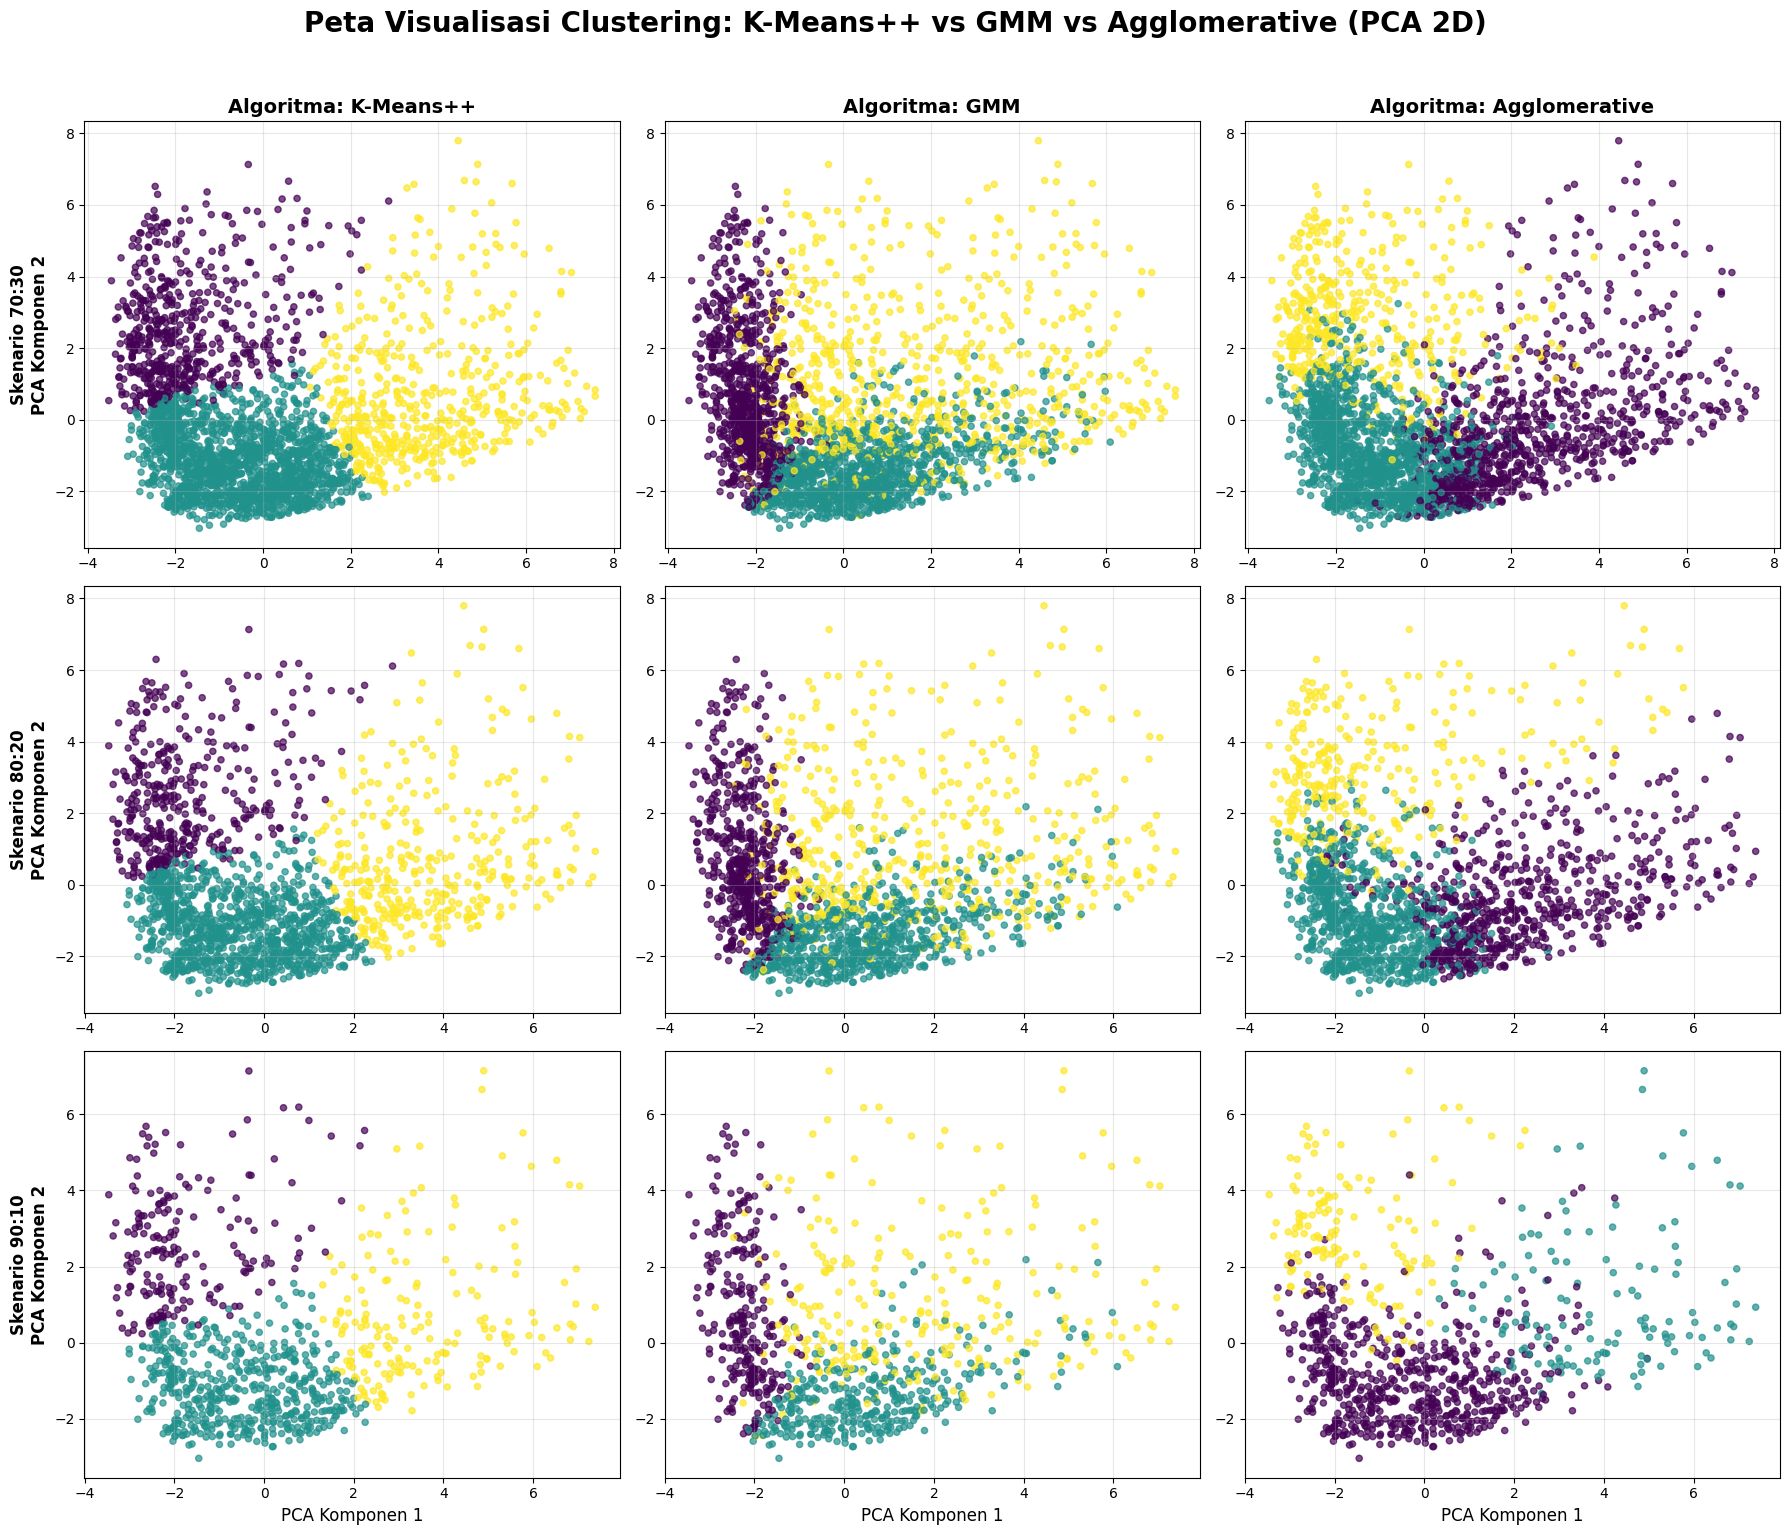

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduksi dimensi ke 2D
pca = PCA(n_components=2, random_state=42)
pca.fit(df_scaled)

# Siapkan Canvas
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Peta Visualisasi Clustering: K-Means++ vs GMM vs Agglomerative (PCA 2D)', fontsize=20, fontweight='bold', y=1.02)

# Label model
nama_model = ['K-Means++', 'GMM', 'Agglomerative']
optimal_k = 3

for i, (nama_skenario, X_train, X_test) in enumerate(scenarios):
    X_test_pca = pca.transform(X_test)

    # K-Means++
    km = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
    labels_km = km.fit(X_train).predict(X_test)

    # GMM
    gmm_model = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
    labels_gmm = gmm_model.fit(X_train).predict(X_test)

    # Agglomerative
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    labels_agglo = agglo.fit_predict(X_test)

    semua_label = [labels_km, labels_gmm, labels_agglo]

    for j in range(3):
        ax = axes[i, j]

        # 🌟 PERUBAHAN WARNA DI SINI: Kembali menggunakan 'viridis'
        scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=semua_label[j], cmap='viridis', alpha=0.7, s=20)

        if i == 0:
            ax.set_title(f"Algoritma: {nama_model[j]}", fontsize=14, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f"Skenario {nama_skenario}\nPCA Komponen 2", fontsize=12, fontweight='bold')
        if i == 2:
            ax.set_xlabel("PCA Komponen 1", fontsize=12)

        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Tahap 7.1: Model Final & Peta Klaster Keseluruhan**

**Penjelasan Tahapan:**
Pada tahap ini, kita melatih model juara kita (**K-Means++ dengan K=3**) menggunakan **100% keseluruhan data nasabah**.
Setelah memastikan skor evaluasi akhirnya tetap solid (tidak terjadi *overfitting*), kita memvisualisasikan hasil pemisahan tersebut menggunakan PCA (reduksi ke 2 dimensi). Visualisasi ini membuktikan bahwa mesin berhasil memotong ribuan nasabah menjadi 3 gumpalan (segmen) yang memiliki pola tersendiri.

--- 🏆 EVALUASI MODEL FINAL (K-Means++, K=3, 100% Data) 🏆 ---
✅ Silhouette Score     : 0.2384
✅ Davies-Bouldin Index : 1.5000



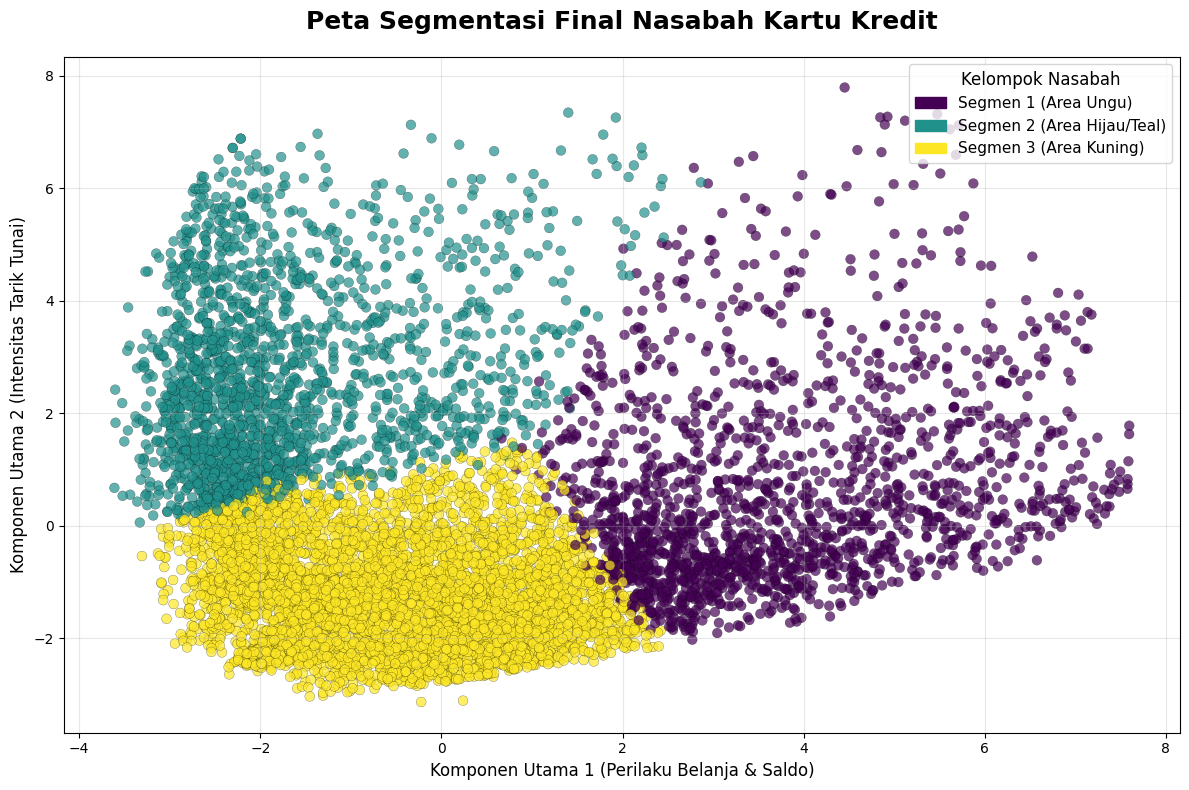

In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Melatih Model Final menggunakan SELURUH data skala
model_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = model_final.fit_predict(df_scaled)

# 2. Evaluasi Final
final_sil_score = silhouette_score(df_scaled, cluster_labels)
final_dbi_score = davies_bouldin_score(df_scaled, cluster_labels)

print("--- 🏆 EVALUASI MODEL FINAL (K-Means++, K=3, 100% Data) 🏆 ---")
print(f"✅ Silhouette Score     : {final_sil_score:.4f}")
print(f"✅ Davies-Bouldin Index : {final_dbi_score:.4f}\n")

# 3. Mereduksi Dimensi untuk Peta Visualisasi (PCA)
pca_final = PCA(n_components=2, random_state=42)
data_pca_final = pca_final.fit_transform(df_scaled)

# 4. Membuat Peta Clustering Final
plt.figure(figsize=(12, 8))
scatter = plt.scatter(data_pca_final[:, 0], data_pca_final[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, s=50, edgecolor='k', linewidth=0.2)

# Menambahkan kosmetik pada grafik
plt.title('Peta Segmentasi Final Nasabah Kartu Kredit', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Komponen Utama 1 (Perilaku Belanja & Saldo)', fontsize=12)
plt.ylabel('Komponen Utama 2 (Intensitas Tarik Tunai)', fontsize=12)

# Membuat Legend Custom untuk Keterangan Segmen di Plot
import matplotlib.patches as mpatches
warna_plot = scatter.cmap(scatter.norm(range(3)))
legenda = [
    mpatches.Patch(color=warna_plot[0], label='Segmen 1 (Area Ungu)'),
    mpatches.Patch(color=warna_plot[1], label='Segmen 2 (Area Hijau/Teal)'),
    mpatches.Patch(color=warna_plot[2], label='Segmen 3 (Area Kuning)')
]
plt.legend(handles=legenda, title="Kelompok Nasabah", fontsize=11, title_fontsize=12, loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Tahap 7.2: Karakteristik Finansial & Profil Bisnis**

**Penjelasan Tahapan:**
Gambar titik-titik pada peta sebelumnya kini akan kita terjemahkan ke dalam nominal uang nyata (Dolar). Kita menempelkan label dari mesin ke data transaksi asli, lalu menghitung nilai **rata-rata (mean)** dari setiap fitur penting (Saldo, Belanja, Tarik Tunai, dan Limit).
Tabel dan diagram batang di bawah ini adalah "Kunci Jawaban" untuk merumuskan strategi promosi dan kebijakan limit kredit.### **Tahap 7.2: Karakteristik Finansial & Profil Bisnis**

**Penjelasan Tahapan:**
Gambar titik-titik pada peta sebelumnya kini akan kita terjemahkan ke dalam nominal uang nyata (Dolar). Kita menempelkan label dari mesin ke data transaksi asli, lalu menghitung nilai **rata-rata (mean)** dari setiap fitur penting (Saldo, Belanja, Tarik Tunai, dan Limit).
Tabel dan diagram batang di bawah ini adalah "Kunci Jawaban" untuk merumuskan strategi promosi dan kebijakan limit kredit.

--- 📊 PROFIL TRANSAKSI RATA-RATA PER SEGMEN (DALAM USD $) 📊 ---


,JUMLAH_NASABAH,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT
Segmen_Nasabah,,,,,,,
Segmen 1,1727,1850.97,2680.15,1498.18,984.98,438.40,6534.82
Segmen 2,1951,3216.12,282.36,177.74,100.64,2701.18,5835.89
Segmen 3,5272,668.69,416.17,203.91,211.08,244.02,3093.21


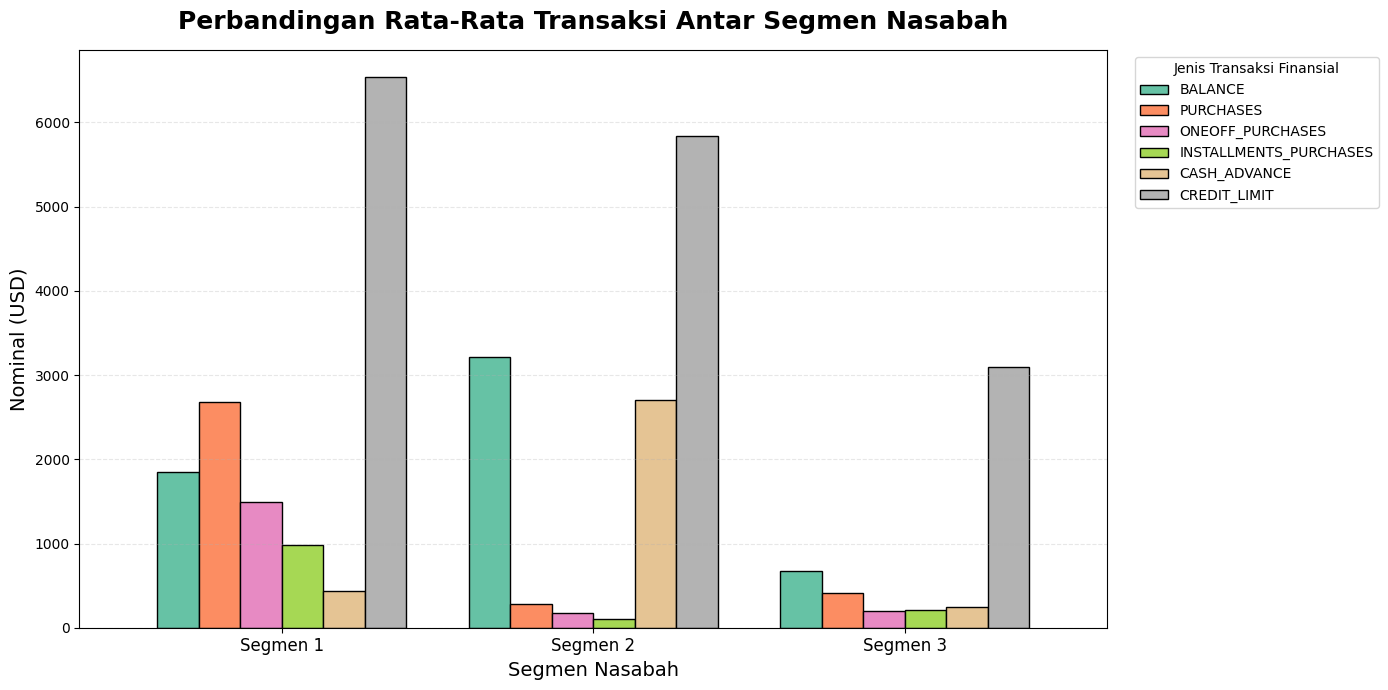

In [11]:
# 1. Menempelkan hasil klaster ke data ASLI (df_clean)
df_final = df_clean.copy()
df_final['Segmen_Nasabah'] = cluster_labels
df_final['Segmen_Nasabah'] = df_final['Segmen_Nasabah'].apply(lambda x: f"Segmen {x+1}")

# 2. Menganalisis Karakteristik Klaster (Menghitung Rata-rata)
kolom_bisnis = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                'CASH_ADVANCE', 'CREDIT_LIMIT']

profil_bisnis = df_final.groupby('Segmen_Nasabah')[kolom_bisnis].mean().round(2)
profil_bisnis['JUMLAH_NASABAH'] = df_final['Segmen_Nasabah'].value_counts()

# Menata ulang urutan kolom agar Jumlah Nasabah ada di depan
cols = ['JUMLAH_NASABAH'] + kolom_bisnis
profil_bisnis = profil_bisnis[cols]

print("--- 📊 PROFIL TRANSAKSI RATA-RATA PER SEGMEN (DALAM USD $) 📊 ---")
display(profil_bisnis)

# 3. Visualisasi Profiling Bisnis (Diagram Batang)
plt.figure(figsize=(14, 7))
ax = profil_bisnis[kolom_bisnis].plot(kind='bar', colormap='Set2', edgecolor='black', ax=plt.gca(), width=0.8)

plt.title('Perbandingan Rata-Rata Transaksi Antar Segmen Nasabah', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Segmen Nasabah', fontsize=14)
plt.ylabel('Nominal (USD)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)

# Menambahkan nilai angka di atas masing-masing batang agar dosen mudah membaca

# for p in ax.patches:
#     ax.annotate(f"{int(p.get_height())}",
#                 (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha='center', va='center',
#                 xytext=(0, 9),
#                 textcoords='offset points',
#                 fontsize=8, rotation=90)

plt.legend(title='Jenis Transaksi Finansial', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### **KESIMPULAN FINAL: PROFILING SEGMEN & STRATEGI BISNIS**

Berdasarkan pemodelan K-Means++ (K=3), kita berhasil memetakan nasabah ke dalam 3 profil unik. Berikut adalah interpretasi bisnis dan rekomendasi **Strategi Limit & Promosi** untuk masing-masing segmen:

#### **🌟 Segmen 1: "The Premium Shoppers" (Sultan Belanja)**
* **Karakteristik (Populasi: 1.727 Nasabah):** Ini adalah segmen nasabah paling berharga (VIP). Mereka sangat aktif menggunakan kartu untuk berbelanja (rata-rata total belanja tertinggi: **\$2.680**). Mereka suka belanja sekali bayar maupun cicilan, namun jarang melakukan tarik tunai. Limit kredit mereka saat ini rata-rata **\$6.534**.
* **Strategi Limit:** **Prioritas Utama Kenaikan Limit!** Berikan penawaran kenaikan batas kredit secara proaktif (misal: naik ke $10.000) untuk memfasilitasi gaya belanja mereka yang tinggi agar tidak *overlimit*.
* **Strategi Promosi:** Tawarkan program loyalitas premium seperti *Air Miles* (tiket pesawat gratis), akses ke *Airport Lounge*, atau *Cashback* persentase tinggi untuk pembelanjaan barang *branded* / elektronik.

#### **🚨 Segmen 2: "The Cash-Advance Relyers" (Nasabah Butuh Dana Cepat)**
* **Karakteristik (Populasi: 1.951 Nasabah):** Nasabah di segmen ini jarang berbelanja barang (hanya **\$282**), namun mereka sangat sering menggunakan fitur Tarik Tunai (*Cash Advance*) dengan rata-rata tertinggi sebesar **\$2.701**. Akibatnya, saldo utang mengendap mereka membengkak (tertinggi di angka **\$3.216**).
* **Strategi Limit:** **Tahan (Hold) Kenaikan Limit.** Nasabah ini memiliki risiko gagal bayar (kredit macet) yang cukup tinggi. Jangan naikkan limit mereka sampai ada tren pelunasan saldo yang sehat.
* **Strategi Promosi:** Jangan tawarkan promo belanja. Tawarkan program **"Restrukturisasi Cicilan"** (mengubah tagihan tarik tunai menjadi cicilan tetap dengan bunga lebih rendah) untuk membantu mereka melunasi utang, atau promo "Bunga Ringan" untuk tarik tunai di bulan-bulan tertentu (seperti menjelang hari raya).

#### **👥 Segmen 3: "The Passive Majority" (Mayoritas Pasif / Pemula)**
* **Karakteristik (Populasi: 5.272 Nasabah):** Ini adalah kelompok terbesar yang mendominasi bank (lebih dari 50% total populasi). Namun, mereka sangat pasif. Rata-rata saldo sangat rendah (**\$668**), belanja minim (**\$416**), dan tarik tunai hampir tidak ada (**\$244**). Limit kredit mereka rata-rata berada di kelas bawah (**\$3.093**).
* **Strategi Limit:** Tidak perlu dinaikkan saat ini, biarkan tetap di limit standar pemula, kecuali jika ada peningkatan aktivitas transaksi yang signifikan.
* **Strategi Promosi:** Tujuan utama di sini adalah **Stimulasi Penggunaan**. Tawarkan promo "Gratis Iuran Tahunan (*Annual Fee*)" jika mereka melakukan minimal 3x transaksi bulan ini. Berikan diskon untuk kebutuhan sehari-hari (seperti *Voucher* Supermarket, Promo Tiket Bioskop Beli 1 Gratis 1, atau Diskon *Food Delivery*) untuk membiasakan mereka menggesek kartu kreditnya.